# **Lab 4.2: Neural Networks (Classification)**

<hr>

## **1. Introduction**
In the previous practice, we learned how to solve regression problems using neural networks. In this session, we will explore how to solve **classification problems**.

Until now, we have focused on binary classification problems, but in this practice, we will also address two new types.

### **Objectives**
In this practice, you will learn to:
* Distinguish between different types of classification problems.
* Modify a neural network to learn classification problems.
* Transform categorical variables into numerical ones.

Let's begin by loading our data once again:

In [2]:
import pandas as pd

seed = 2533
data = pd.read_pickle('https://raw.githubusercontent.com/AIC-Uniovi/Sistemas-Inteligentes/refs/heads/main/datasets/f1_23_monaco.pkl')

<hr>

## **2. Binary Classification Problems**

Let's try to solve a problem similar to the one in Practice 3 on classification, that is:

<div class="alert alert-block alert-success">
    <b>Create a model that, given the time (in seconds) of the first two sectors of an <i>Aston Martin</i> driver (<code>'Sector1Time', 'Sector2Time'</code>), predicts whether that time was set by <i>Alonso</i> or not (<i>Stroll</i>).</b>
</div>

As always, the first step is to create the necessary datasets to train a model.

### **2.1. Data Preprocessing**

We create the variable <code>data_aston</code> with the rows and columns needed to train our models.

In [3]:
data_aston = data.loc[data.Team == 'Aston Martin'][['Sector1Time', 'Sector2Time', 'Driver']].copy()
data_aston['Sector1Time'] = data_aston['Sector1Time'].dt.total_seconds()
data_aston['Sector2Time'] = data_aston['Sector2Time'].dt.total_seconds()

<div class="alert alert-block alert-info">
    <b>Exercise:</b> Create the <code>Class</code> column in the <code>data_aston</code> DataFrame so that it is zero whenever the driver is not Alonso, and 1 otherwise.
</div>

In [4]:
# Your code here
data_aston['Class'] = data_aston['Driver'].apply(lambda x: 1 if x=='ALO' else 0)
data_aston

,Sector1Time,Sector2Time,Driver,Class
1,20.871,37.656,ALO,1
16,21.136,37.566,STR,0
18,20.649,37.348,ALO,1
33,21.084,37.647,STR,0
38,20.584,37.221,ALO,1
...,...,...,...,...
1174,23.068,42.166,ALO,1
1192,22.592,41.209,ALO,1
1209,23.072,41.645,ALO,1
1227,22.164,40.949,ALO,1


<div class="alert alert-block alert-info">
    <b>Exercise:</b> Separate the X and Y from the <code>data_aston</code> DataFrame, split them into training and test sets (80/20) setting the random seed, and finally <b>standardize</b> the X variables.
</div>

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Your code here
X = data_aston[['Sector1Time', 'Sector2Time']]
y = data_aston['Class'] 

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed)

sc = StandardScaler()
Xtr_s = sc.fit_transform(Xtr)
Xte_s = sc.transform(Xte)

### **2.2. Machine Learning**

With the data ready, we will once again train and evaluate the machine learning models we already know, so we can compare them with our new system.

<div class="alert alert-block alert-info">
    <b>Exercise:</b> Train and evaluate the remaining models (<i>Logistic Regression</i>, <i>K-Nearest Neighbors</i>, <i>Decision Trees</i>, and <i>SVC</i>) using the following function.
</div>

In [6]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

def evaluate_model(yte, preds_test, model_name, average="binary"):
    metrics = {
        "Métrica": ["Accuracy", "F1"],
        "TEST": [accuracy_score(yte, preds_test), f1_score(yte, preds_test, average=average)]
    }
    df = pd.DataFrame(metrics)
    print(f"Results for {model_name}:")
    print(df.to_string(index=False))
    print()

# Baseline Random
baseline_random = DummyClassifier(strategy = 'uniform')
baseline_random.fit(Xtr_s, ytr)
preds_test = baseline_random.predict(Xte_s)
evaluate_model(yte, preds_test, 'Baseline Random')

# Baseline Zero-R
baseline_zero = DummyClassifier(strategy = 'most_frequent')
baseline_zero.fit(Xtr_s, ytr)
preds_test = baseline_zero.predict(Xte_s)
evaluate_model(yte, preds_test, 'Baseline Zero-R')

# Your code here

lr = LogisticRegression()
lr.fit(Xtr_s, ytr)
preds_test = lr.predict(Xte_s)
evaluate_model(yte, preds_test, 'Logistic Regression')

knn = KNeighborsClassifier()
knn.fit(Xtr_s, ytr)
preds_test = knn.predict(Xte_s)
evaluate_model(yte, preds_test, 'K-Nearest Neighbours')

tree = DecisionTreeClassifier()
tree.fit(Xtr_s, ytr)
preds_test = tree.predict(Xte_s)
evaluate_model(yte, preds_test, 'Decision Trees')

svc = SVC()
svc.fit(Xtr_s, ytr)
preds_test = svc.predict(Xte_s)
evaluate_model(yte, preds_test, 'SVC')

rf = RandomForestClassifier()
rf.fit(Xtr_s, ytr)
preds_test = rf.predict(Xte_s)
evaluate_model(yte, preds_test, 'Random forest')

Results for Baseline Random:
 Métrica     TEST
Accuracy 0.608696
      F1 0.689655

Results for Baseline Zero-R:
 Métrica     TEST
Accuracy 0.565217
      F1 0.722222

Results for Logistic Regression:
 Métrica     TEST
Accuracy 0.565217
      F1 0.722222

Results for K-Nearest Neighbours:
 Métrica     TEST
Accuracy 0.956522
      F1 0.962963

Results for Decision Trees:
 Métrica     TEST
Accuracy 0.826087
      F1 0.866667

Results for SVC:
 Métrica     TEST
Accuracy 0.913043
      F1 0.928571

Results for Random forest:
 Métrica     TEST
Accuracy 0.956522
      F1 0.962963



The results should look something like this:

<center>

| Model                 | Accuracy (test) | F1 (test) |
|-----------------------|-----------------|-----------|
| Baseline Random       | 0.522           | 0.560     |
| Baseline Zero-R       | 0.565           | 0.722     |
| Logistic Regression   | 0.565           | 0.722     |
| KNN                   | 0.957           | 0.963     |
| Decision Trees        | 0.826           | 0.867     |
| SVC                   | 0.913           | 0.929     |

</center>

##### **Visualizing Data and Models**

In this case, our problem has two inputs and one output (the class). As we saw in the regression part, working with such low dimensions allows us to visualize the behavior of the data and the models we are learning.

Thanks to this possibility, we can analyze in advance whether the relationship between the inputs and outputs can be solved with linear models or, on the other hand, requires a non-linear approach.

Below is the function that visualizes the data and, given a model, makes a series of predictions to draw its **decision boundary**:

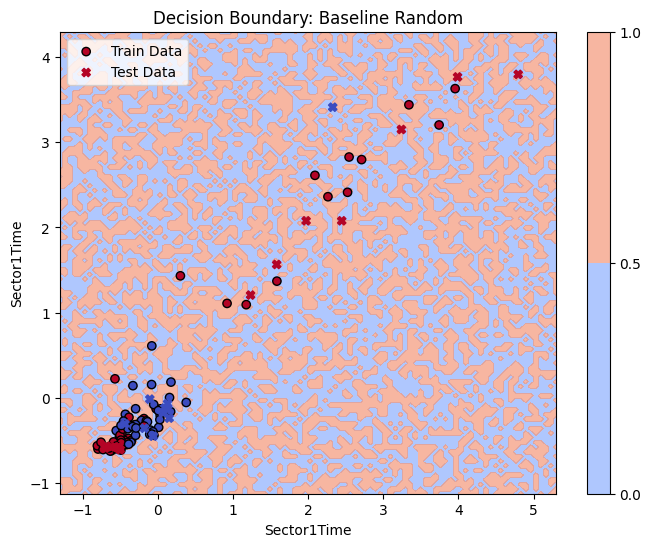

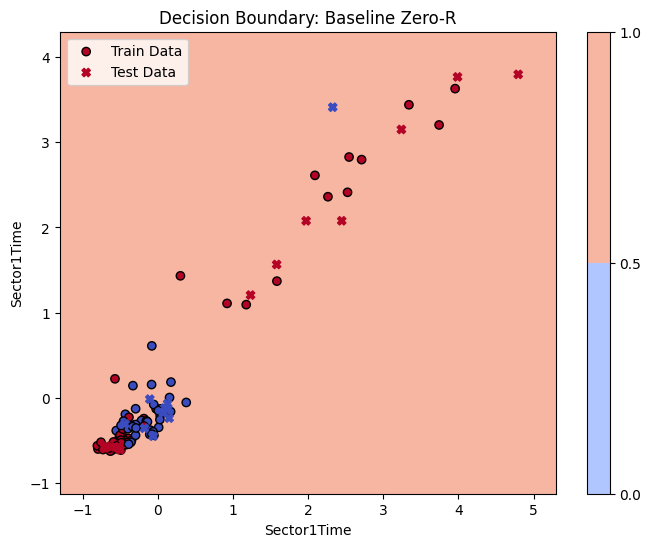

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Function to visualize data and model decision boundary
def plot_decision_boundary(Xtr, ytr, Xte, yte, model, model_name):
    plt.figure(figsize = (8, 6))

    # Create a mesh grid of points within the range of Train and Test data
    x_min, x_max = min(Xtr[:, 0].min(), Xte[:, 0].min()) - 0.5, max(Xtr[:, 0].max(), Xte[:, 0].max()) + 0.5
    y_min, y_max = min(Xtr[:, 1].min(), Xte[:, 1].min()) - 0.5, max(Xtr[:, 1].max(), Xte[:, 1].max()) + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predict the probability for each point in the mesh
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    # Draw the decision boundary
    contour = plt.contourf(xx, yy, Z, levels = [0, 0.5, 1], alpha = 0.7, cmap = 'coolwarm')

    # Add colorbar
    plt.colorbar(contour)

    # Visualize the Train points
    plt.scatter(Xtr[:, 0], Xtr[:, 1], c = ytr, cmap = 'coolwarm', edgecolors = 'k', label = 'Train Data')
    
    # Visualize the Test points
    plt.scatter(Xte[:, 0], Xte[:, 1], c = yte, cmap = 'coolwarm', marker = 'X', label = 'Test Data')

    # Labels and legend
    plt.xlabel('Sector1Time')
    plt.ylabel('Sector1Time')
    plt.title(f'Decision Boundary: {model_name}')
    plt.legend()
    plt.show()

plot_decision_boundary(Xtr_s, ytr, Xte_s, yte, baseline_random, 'Baseline Random')
plot_decision_boundary(Xtr_s, ytr, Xte_s, yte, baseline_zero, 'Baseline Zero-R')

<div class="alert alert-block alert-info">
    <b>Exercise:</b> Plot the decision boundary for the remaining models and try to understand the results.
</div>

/Users/samuel/Código/University/venv_stable/lib/python3.11/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/samuel/Código/University/venv_stable/lib/python3.11/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/samuel/Código/University/venv_stable/lib/python3.11/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


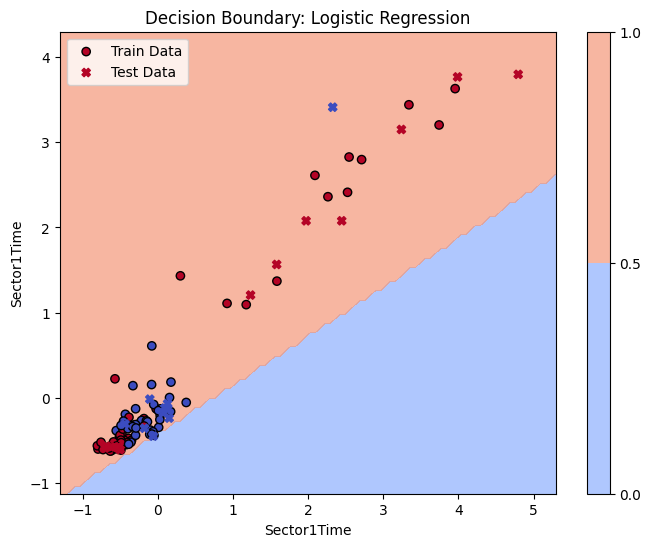

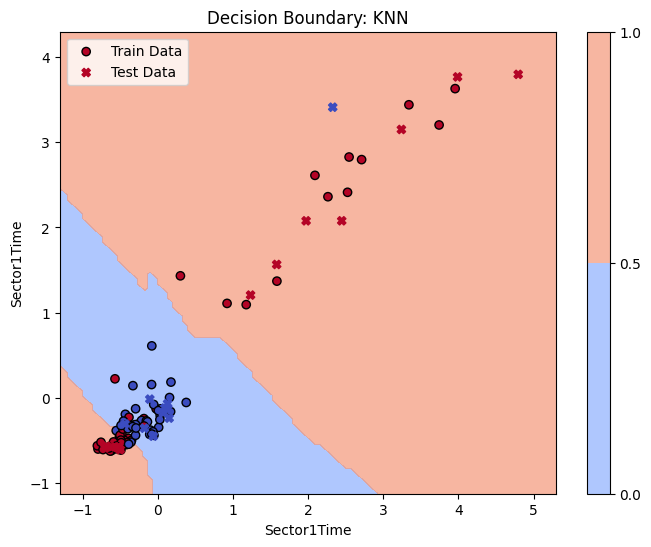

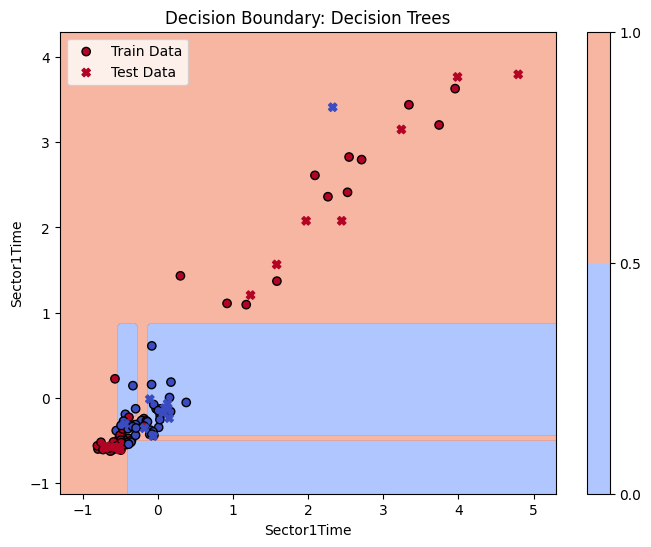

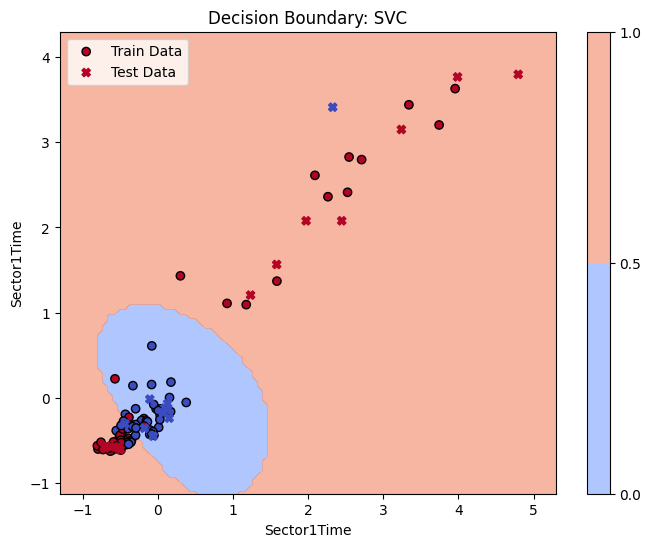

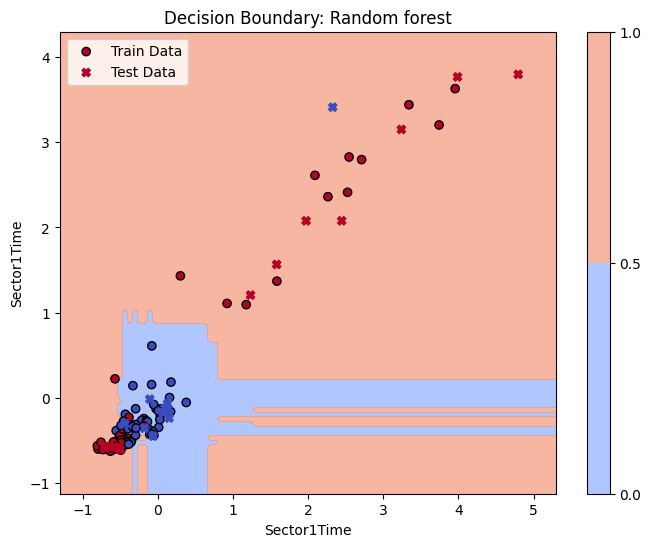

In [8]:
# Your code here
plot_decision_boundary(Xtr_s, ytr, Xte_s, yte, lr, 'Logistic Regression')
plot_decision_boundary(Xtr_s, ytr, Xte_s, yte, knn, 'KNN')
plot_decision_boundary(Xtr_s, ytr, Xte_s, yte, tree, 'Decision Trees')
plot_decision_boundary(Xtr_s, ytr, Xte_s, yte, svc, 'SVC')
plot_decision_boundary(Xtr_s, ytr, Xte_s, yte, rf, 'Random forest')

<div class="alert alert-block alert-info">
    <b>Exercise:</b> Do you think the problem is linear or non-linear? Analyzing the decision boundaries, which models are non-linear?
</div>

Your answer here

### **2.3. Neural Network**

Now we will create a neural network from scratch to solve this problem. Remember that the steps are as follows:

1) Create the model architecture.
2) Specify the optimizer, loss function, and compile.
3) Train and evaluate.

We will set the seeds and create the function to plot the model's training evolution:

In [9]:
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import pandas as pd
import numpy as np
import os, random

# Set the libraries' seeds so that the results are reproducible.
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

def plot_loss_history(history):
    # Extract history data
    loss = history.history['loss']
    val_loss = history.history.get('val_loss', []) # Empty by default
    epochs = range(1, len(loss) + 1)
    # Construct the DataFrame
    data = pd.DataFrame({ 'Epoch': epochs, 'Loss': loss, 'Type': 'Train' })
    # If validation exist, use the data
    if val_loss:
        val_df = pd.DataFrame({ 'Epoch': epochs, 'Loss': val_loss, 'Type': 'Validation' })
        data = pd.concat([data, val_df], ignore_index=True)
    # Create the graph
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=data, x="Epoch", y="Loss", hue="Type")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss evolution during training")
    plt.grid(True, linestyle='--', alpha=0.7)
    # Show legend only if needed
    if val_loss: plt.legend(title="Dataset")
    else: plt.legend().remove() # Avoid empty legends
    plt.show()

##### **Final layer activation and loss**

As mentioned in the previous lab, when creating a neural network, it is crucial to appropriately select both the **final layer activation function** and the **loss function**.

In a regression problem, the last layer generally does not use an activation function to prevent predictions from being limited to a specific range. However, if the values being predicted are always positive, a *ReLU* function could be applied.

<center>
    <div style="border-radius:5px; padding:10px; background:white; max-width:900px">
        <img src="https://i.imgur.com/e7kd5fs.png">   
    </div>
</center>

We are now facing a **binary classification** problem, where we seek to predict a probability, that is, a value between 0 and 1. Consequently, we must employ a **sigmoid** function as the activation function in the final layer.

<div class="alert alert-block alert-warning">
    <strong>Note:</strong> Remember that a neural network that <b>only</b> has an activation function in the last layer <b>cannot learn non-linear problems</b>; for that, activation functions in the hidden layers are required.
</div>

Another element we need to change compared to regression problems is the **loss function**.

<div class="alert alert-block alert-warning">
    <strong>Note:</strong> In a binary classification problem, you should not use loss functions designed for regression, such as <b>mean absolute error</b> (MAE), as they are geared toward problems where the outputs <b>are continuous values and not probabilities</b>.
</div>

Therefore, in addition to adding a sigmoid to the output layer, we will also have to change the loss function to **Binary Crossentropy**. This leaves us with the following table:

<center>

| Problem Type | Final layer activation function | Loss function | In *Keras* |
| :--- | :--- | :--- | :--- |
| *Regression* | None or *ReLU* (if values are positive) | *MAE* or *MSE* | `mean_absolute_error` or `mean_squared_error` |
| *Binary Classification* | *Sigmoid* | *Binary Crossentropy* | `binary_crossentropy` |

</center>

##### **Activation in the Last Layer and Loss**

As mentioned in the previous practice, when creating a neural network, it is crucial to properly select both the **activation function of the last layer** and the **loss function**.

In a regression problem, the last layer generally does not use an activation function to avoid limiting the predictions to a specific range. However, if the values being predicted are always positive, a *ReLU* function could be applied.

<center>
    <div style="border-radius:5px; padding:10px; background:white; max-width:900px">
        <img src="https://i.imgur.com/e7kd5fs.png">   
    </div>
</center>

Now, we are facing a **binary classification** problem, where we seek to predict a probability, i.e., a value between $0$ and $1$. Therefore, we need to use a **sigmoid** activation function in the final layer.

<div class="alert alert-block alert-warning">
    <strong>Note:</strong> Remember that a neural network with a <b>single</b> activation function in the last layer <b>cannot learn non-linear problems</b>; activation functions are required in the hidden layers for that.
</div>

Another aspect we need to change compared to regression problems is the **loss function**.

<div class="alert alert-block alert-warning">
    <strong>Note:</strong> In a binary classification problem, loss functions designed for regression, such as <b>mean absolute error</b> (MAE), should not be used, as they are oriented to problems where the outputs are <b>continuous values, not probabilities</b>.
</div>

Therefore, in addition to adding a sigmoid to the output layer, we must also change the loss function to **Binary Crossentropy**. This leaves us with the following table:

<center>

| Problem Type                 | Activation Function in Last Layer           | Loss Function          | In *Keras*                                |
|------------------------------|--------------------------------------------|------------------------|-------------------------------------------|
| *Regression*                 | None or *ReLU* (if values are positive)   | *MAE* or *MSE*         | `mean_absolute_error` or `mean_squared_error` |
| *Binary Classification*      | *Sigmoid*

<center>

<div class="alert alert-block alert-info">
    <b>Exercise:</b> Create, within the provided function, a <b>binary classification</b> neural network with a single layer. Train it, plot the evolution of the loss using the <code>plot_loss_history</code> function, and analyze its decision boundary.
    <hr>
    Train with a validation set of 20%, for 300 epochs, with a batch size of 16 and a learning rate of 0.005.
</div>

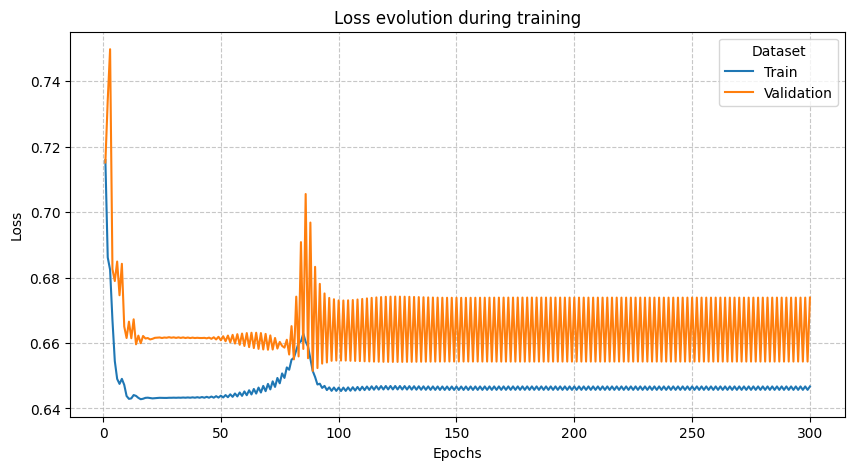

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 180us/step


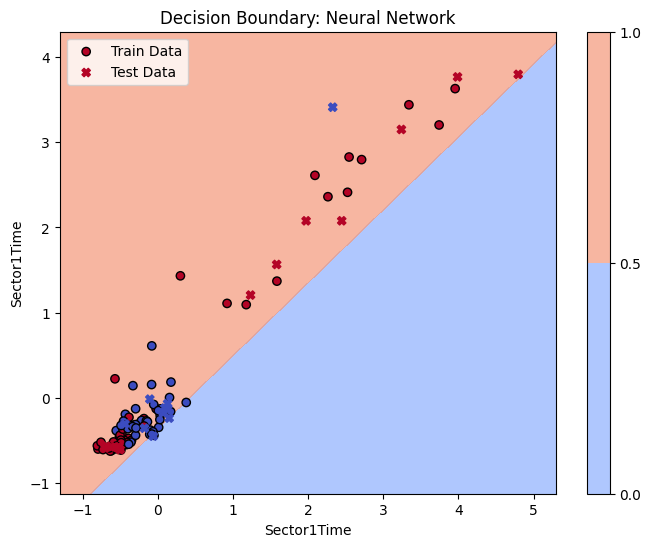

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
def neural_network_one(learning_rate):
    # Create and compile the model
    # Your code here

    model = Sequential()
    model.add(Input(shape=(2,)))
    model.add(Dense(1, activation="sigmoid", name="output-layer"))

    optim = Adam(learning_rate = learning_rate)
    model.compile(loss="binary_crossentropy", optimizer=optim)

    return model

# Create the neural network from scratch
model_1 = neural_network_one(learning_rate = 0.5)

# Train the model
# Your code here
history = model_1.fit(Xtr_s, ytr, validation_split = 0.2, batch_size = 16, epochs = 300, verbose = 0)

# Visualize training
# Your code here

plot_loss_history(history)
# Decision boundary
# Your code here
plot_decision_boundary(Xtr_s, ytr, Xte_s, yte, model_1, 'Neural Network')

<div class="alert alert-block alert-info">
    <b>Exercise:</b> Evaluate the previous model on Test using <code>.predict()</code> and <code>evaluate_model</code>. Add the result to the table.
    <hr>
    In this case, we are <b>not</b> going to try to find the best hyperparameters; as you have seen, this model is linear and will not be able to solve our non-linear problem.
</div>

<div class="alert alert-block alert-warning">
    <strong>Note:</strong> Neural networks do not natively return binary values (0 or 1), but rather probabilities (decimal values). Metrics do not allow decimals.
    <hr>
    To obtain the metrics, you must apply a decision threshold. Commonly, 0.5 is used to convert values above this threshold into 1 and values below it into 0.
</div>

<center>

| Model                  | Accuracy (test) | F1 (test) |
|------------------------|-----------------|-----------|
| Baseline Random        | 0.522           | 0.560     |
| Baseline Zero-R        | 0.565           | 0.722     |
| Logistic Regression    | 0.565           | 0.722     |
| KNN                    | 0.957           | 0.963     |
| Decision Trees         | 0.826           | 0.867     |
| SVC                    | 0.913           | 0.929     |
| Linear Neural Network  | 0.565           | 0.722     |

</center>

In [11]:
# Evaluate
# Your code here

y_pred = model_1.predict(Xte_s, verbose=0)
y_pred = y_pred > 0.5
evaluate_model(yte, y_pred, 'Neural Network')

Results for Neural Network:
 Métrica     TEST
Accuracy 0.652174
      F1 0.764706



<div class="alert alert-block alert-info">
    <b>Exercise:</b> Create a <u>non-linear</u> binary classification neural network and search for the best learning rate. Train the final model with the best hyperparameter and evaluate it on test. Fill in both tables.
    <hr>
    Set the validation set to 20%, epochs to 500, and batch size to 16. For training the final model, a validation set is not necessary.
    <hr style="margin-bottom:5px">
    Also, visualize the decision boundary to verify that the learned model is non-linear.
</div>

<center>

| Model                       | Accuracy (train)  | F1 (train) | Accuracy (val)  | F1 (val) |
|-----------------------------|-------------------|------------|-----------------|----------|
| *Neural Network (lr=0.001)*  |                   |            |                 |          |
| *Neural Network (lr=0.005)*  |                   |            |                 |          |
| *Neural Network (lr=0.01)*   |                   |            |                 |          |

</center>

<br>

<center>

| Model                     | Accuracy (test) | F1 (test) |
|---------------------------|-----------------|-----------|
| Baseline Random           | 0.522           | 0.560     |
| Baseline Zero-R           | 0.565           | 0.722     |
| Logistic Regression       | 0.565           | 0.722     |
| KNN                       | 0.957           | 0.963     |
| Decision Trees            | 0.826           | 0.867     |
| SVC                       | 0.913           | 0.929     |
| Linear Neural Network     |                 |           |
| Non-Linear Neural Network |                 |           |

</center>

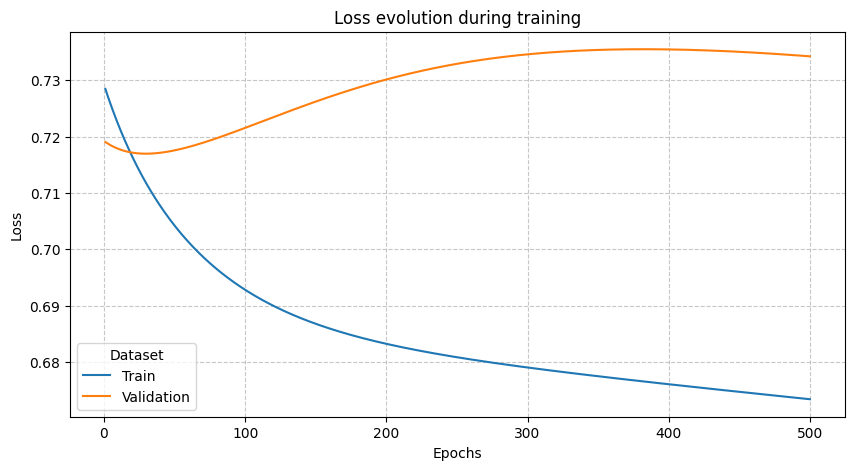

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 181us/step


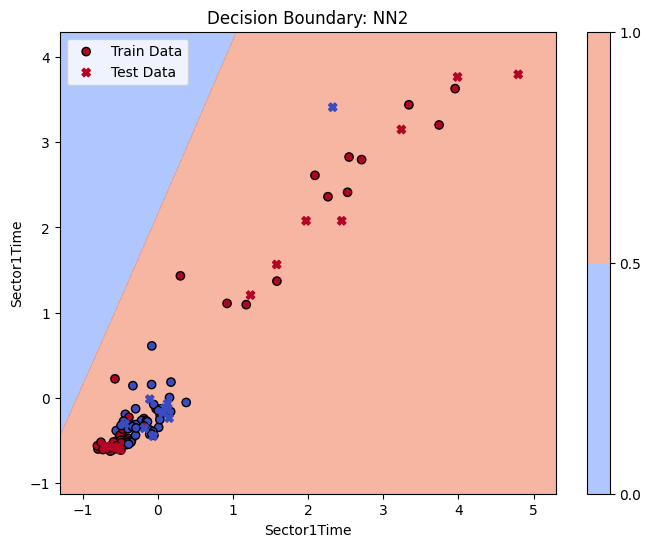

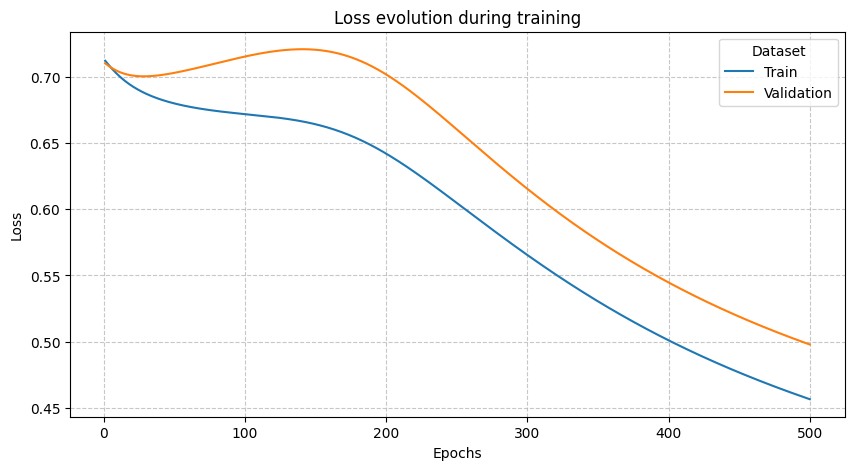

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 180us/step


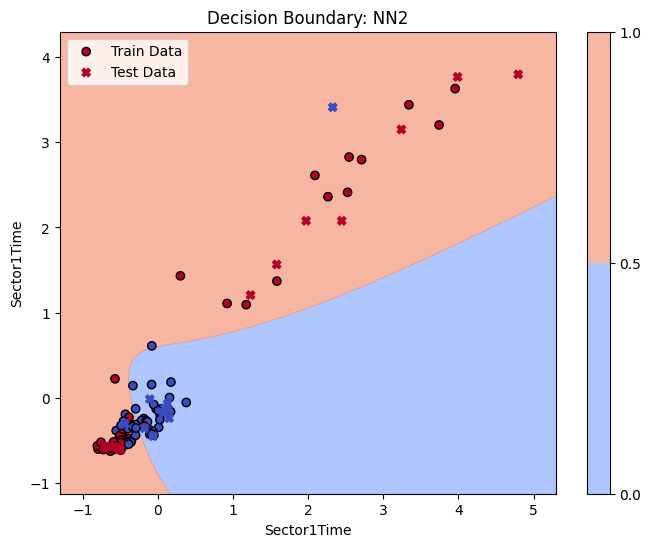

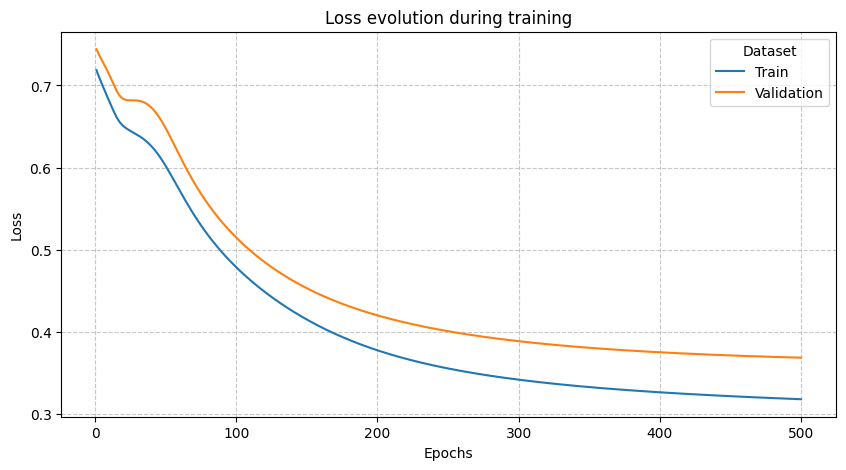

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 179us/step


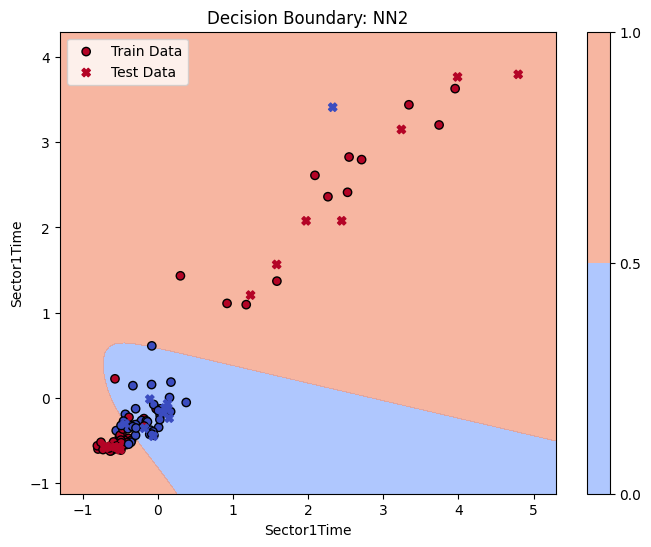

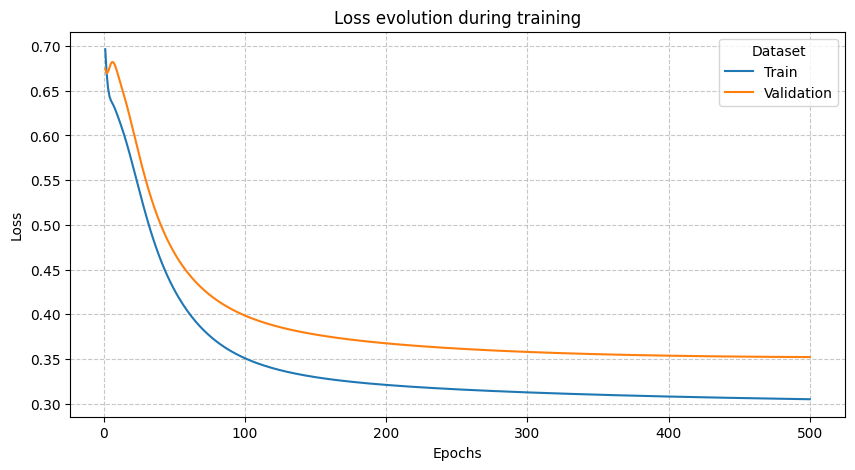

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 182us/step


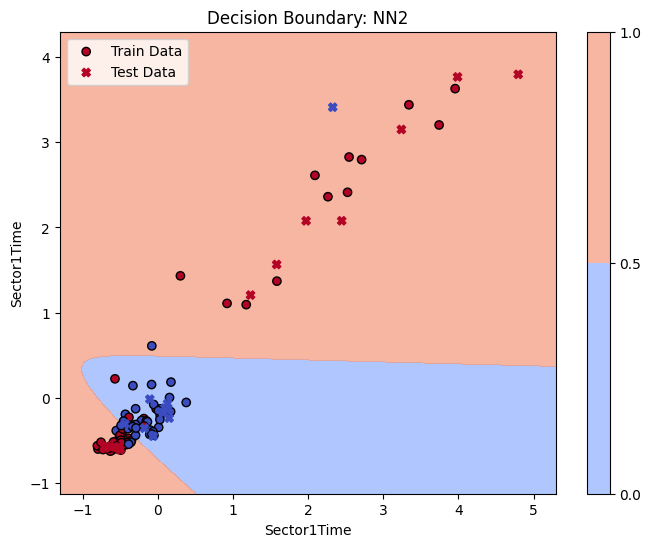

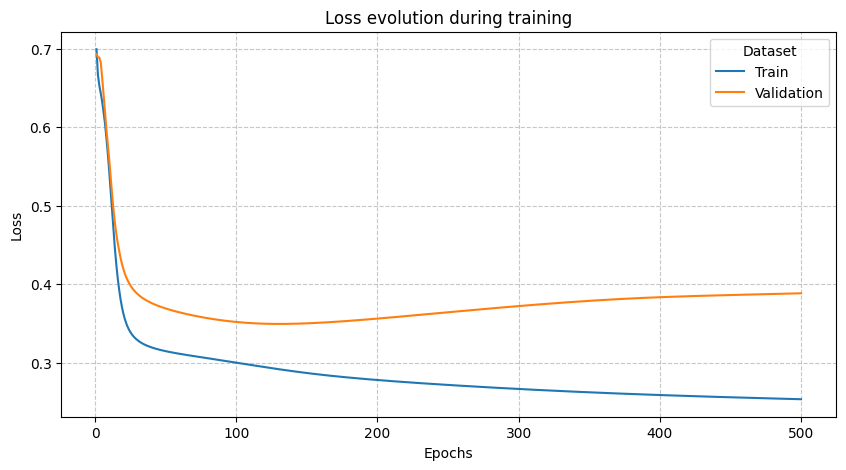

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 183us/step


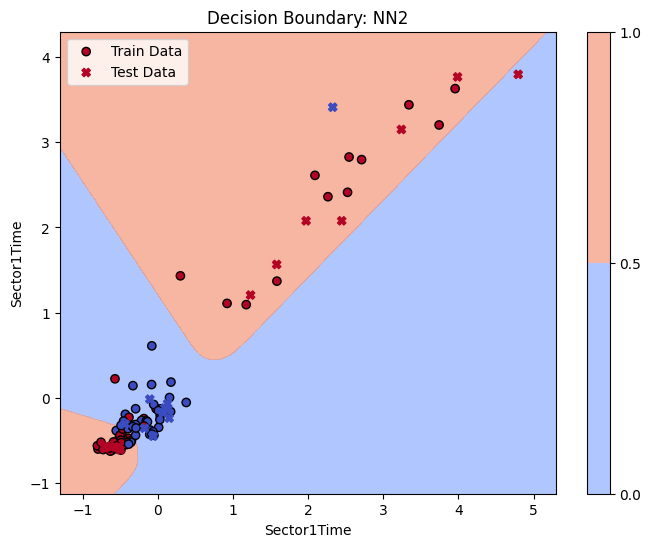

In [12]:
def neural_network_two(learning_rate):
    # Create and compile the model
    
    # Your code here

    model = Sequential()
    model.add(Input(shape=(2,)))
    model.add(Dense(3, activation="tanh"))
    model.add(Dense(1, activation="sigmoid"))

    optim = Adam(learning_rate = learning_rate)
    model.compile(loss="binary_crossentropy", optimizer=optim)

    return model

# Create the neural network from scratch
learningRate = [0.0005, 0.001, 0.005, 0.01, 0.05]
for lr in learningRate:
    model_2 = neural_network_two(learning_rate = lr)

    # Train the model
    # Your code here
    history = model_2.fit(Xtr_s, ytr, validation_split = 0.2, batch_size = 16, epochs = 500, verbose = 0)


    # Visualize training
    # Your code here
    plot_loss_history(history)

    # Repeat for another hyperparameter value
    plot_decision_boundary(Xtr_s, ytr, Xte_s, yte, model_2, 'NN2')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Results for NN3:
 Métrica     TEST
Accuracy 0.521739
      F1 0.560000

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 157us/step


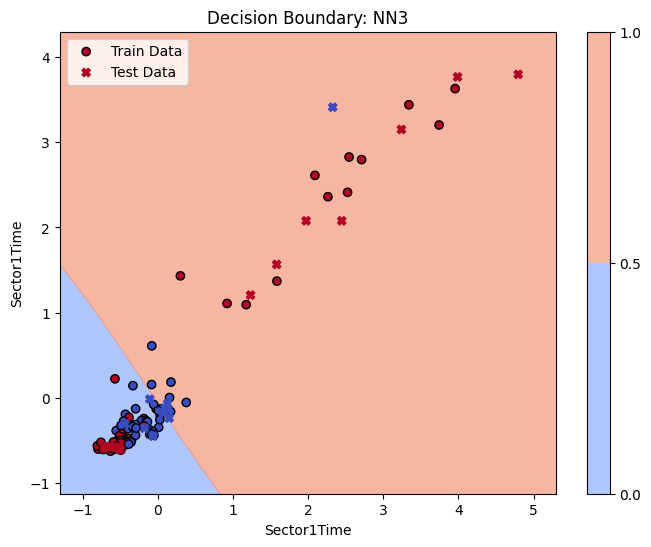

In [13]:
# Train final model (without validation)
# Your code here
model_3 = neural_network_two(learning_rate=0.005)
history = model_3.fit(Xtr_s, ytr, validation_split = 0.2, batch_size = 16, verbose=0)
# Evaluate on test
# Your code here
preds_test = model_3.predict(Xte_s)
preds_test = preds_test > 0.5
evaluate_model(yte, preds_test, "NN3")

# Decision boundary
# Your code here
plot_decision_boundary(Xtr_s, ytr, Xte_s, yte, model_3, 'NN3')

<div class="alert alert-block alert-info">
    <b>Exercise:</b> Visit the following website to view the training and decision boundaries of a neural network for various binary classification problems: <a href="https://playground.tensorflow.org/">https://playground.tensorflow.org/</a>
</div>

<hr>

## **3. Multi-classification Problems**

So far, our classification problems have always focused on binary classification, but as you know, there are more types of problems in this area.

Now we will try to solve a **multi-class** problem, that is, a problem where each example can belong **to one of several possible classes**.

<div class="alert alert-block alert-success">
    <b>Create a model that, given the time (in seconds) of the sectors (<code>"Sector1Time", "Sector2Time" and "Sector3Time"</code>), the speeds (<code>"SpeedI1", "SpeedI2", "SpeedFL" and "SpeedST"</code>) and tire data (<code>"Compound" and "TyreLife"</code>), is able to predict the <i>team</i> (<code>"Team"</code>) of the car that made that lap.</b> 
</div>
  
As always, the first step will be to create the necessary datasets to train our model.

### **3.1. Data Preprocessing**

We create the <code>data_teams</code> variable with the rows and columns necessary to train our models.

In [14]:
relevant_cols = ['Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'Compound', 'TyreLife', 'Team']
data_teams = data[relevant_cols].copy()
data_teams = data_teams.dropna().reset_index(drop = True) # Remove rows with any null value

data_teams['Sector1Time'] = data_teams['Sector1Time'].dt.total_seconds()
data_teams['Sector2Time'] = data_teams['Sector2Time'].dt.total_seconds()
data_teams['Sector3Time'] = data_teams['Sector3Time'].dt.total_seconds()

<div class="alert alert-block alert-info">
    <b>Exercise:</b> Create a <code>countplot()</code> of the <code>"Team"</code> column from the DataFrame <code>data_teams</code> to check if there is any class imbalance. Do you think there is?
</div>

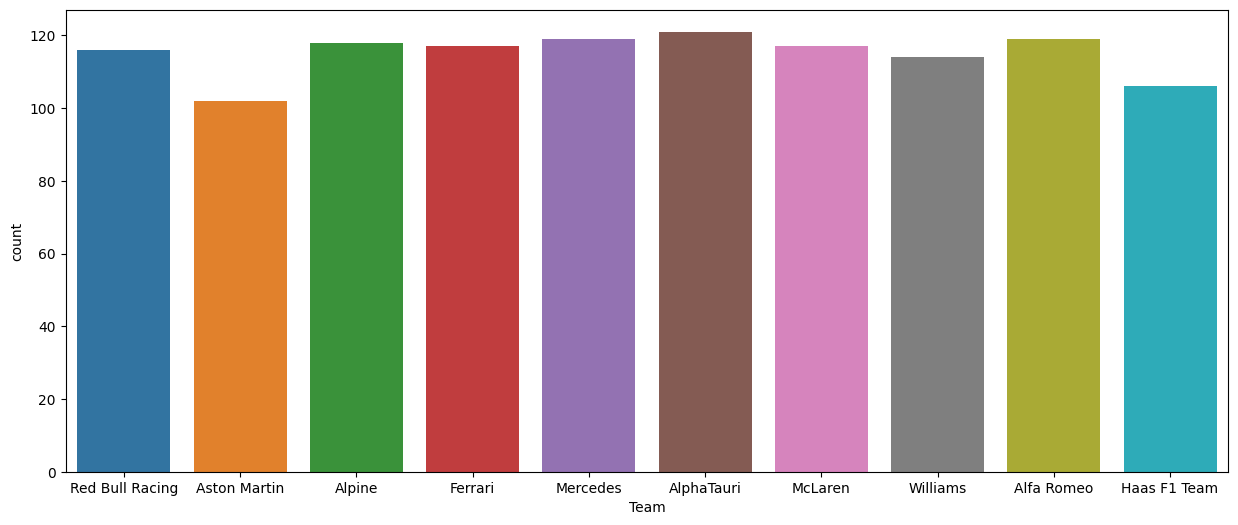

In [15]:
plt.figure(figsize = (15,6))

# Your code her
sns.countplot(data_teams, x="Team", hue="Team")

plt.show()

##### **Encoding: From Categories to Numbers**

Models only understand numbers, but the way we prepare data varies depending on whether we are setting up the **inputs** or the **output**, and according to the **library** we are using.

<div class="alert alert-block alert-warning">
    <strong>Note:</strong> Inputs (X) must always be numerical for all models and libraries.
    <br>
    Outputs (y) are only mandatory to encode for Neural Networks.
</div>

**Libraries**

Both *Scikit-Learn* and *Keras* **always** require **input** features to be numbers. The main difference is found in the **outputs**:

* **Scikit-Learn:** Allows us to pass the target variable `Team` directly as **text**. The model takes care of mapping these labels automatically during training.
* **Keras:** Neural networks do not have this automatic management. For the output layer to function (especially with *Softmax*), we must manually transform text labels into **numerical vectors (One-Hot)** before training.



**Encoding (Input or Output)**

* **Binary Variables:** (e.g., 'Yes'/'No' or 'Alonso'/'Stroll') we convert these into $0$ and $1$.
* **Variables with Multiple Categories:** (e.g., the `Compound` variable). We cannot use correlative numbers (1, 2, 3...) because the model would think one category is "greater" than another. We use **One-Hot Encoding** to create independent columns of zeros and ones.

<div class="alert alert-block alert-info">
    <b>Exercise:</b> Use the <code>pd.get_dummies()</code> method from <code>pandas</code> passing <code>data_teams, dtype=int</code> as parameters. What happens?
    <hr>
    Once you understand it, overwrite <code>data_teams</code>.
</div>

In [16]:
# Testing zone

In [17]:
y_sk = data_teams["Team"] # We save the column of original labels for the sklearn models
data_teams = pd.get_dummies(data_teams, dtype=int)# Your code here

<div class="alert alert-block alert-info">
    <b>Exercise:</b> Separate X and Y from the <code>data_teams</code> dataframe, split them into training and testing sets (including <code>Y_sk</code>) (80/20) by fixing the random seed, and finally <b>normalize</b> the X sets using the <code>MinMaxScaler()</code> class.
</div>

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

X_cols = ['Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'TyreLife', 'Compound_HARD', 'Compound_INTERMEDIATE', 'Compound_MEDIUM', 'Compound_SOFT', 'Compound_WET']
y_keras_cols = ['Team_Alfa Romeo', 'Team_AlphaTauri', 'Team_Alpine', 'Team_Aston Martin', 'Team_Ferrari', 'Team_Haas F1 Team', 'Team_McLaren', 'Team_Mercedes', 'Team_Red Bull Racing', 'Team_Williams']

# Your code here
X = data_teams[X_cols]
y = data_teams[y_keras_cols]
# X_train, X_test, Y_train, Y_test, Y_sk_train, Y_sk_test = ...
Xtr, Xte, ytr, yte, ytr_sk, yte_sk = train_test_split(X, y, y_sk, test_size=0.2, random_state=seed)

sc = MinMaxScaler()
Xtr_s = sc.fit_transform(Xtr)
Xte_s = sc.transform(Xte)

       Sector1Time  Sector2Time  Sector3Time      SpeedI1      SpeedI2  \
count  1149.000000  1149.000000  1149.000000  1149.000000  1149.000000   
mean     21.688849    39.292984    21.729174   181.098346   177.377720   
std       2.045096     3.868982     1.613253    24.397262    17.977582   
min      19.730000    35.647000    20.059000    98.000000   118.000000   
25%      20.374000    36.740000    20.787000   166.000000   174.000000   
50%      20.755000    37.254000    21.059000   191.000000   185.000000   
75%      22.446000    41.567000    21.919000   199.000000   189.000000   
max      29.612000    50.418000    29.105000   212.000000   197.000000   

           SpeedFL      SpeedST     TyreLife  Compound_HARD  \
count  1149.000000  1149.000000  1149.000000    1149.000000   
mean    258.095735   275.105309    20.610966       0.467363   
std       5.908674    10.595766    13.274872       0.499151   
min     190.000000   157.000000     2.000000       0.000000   
25%     256.000000

### **3.2. Machine Learning**

With the data ready, we will train and evaluate the machine learning models we already know to compare them with our new system.

<div class="alert alert-block alert-warning">
    <strong>Note:</strong> The <code>f1_score</code> metric can be obtained in different ways for multi-class problems:
    <ul>
        <li><strong>micro</strong>: Calculates the global metric considering all samples, without distinguishing between classes. It's useful when the classes are imbalanced.</li>
        <li><strong>macro</strong>: Calculates the metric for each class separately and then takes the arithmetic average. It gives equal weight to all classes, regardless of their frequency.</li>
        <li><strong>weighted</strong>: Similar to macro, but weights each class according to its number of samples. It's useful when the classes are imbalanced.</li>
        <li><strong>samples</strong>: Used in multi-label problems, calculating the metric for each sample and then averaging it.</li>
    </ul>
</div>

As you saw in the previous histogram, the classes are balanced, so we can use `macro`.

In [19]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

# Baseline Random
baseline_random = DummyClassifier(strategy="uniform")
baseline_random.fit(Xtr_s, ytr_sk)
preds_test = baseline_random.predict(Xte_s)
evaluate_model(yte_sk, preds_test, "Baseline Random", average="macro")

# Baseline Zero-R
baseline_zero = DummyClassifier(strategy="most_frequent")
baseline_zero.fit(Xtr_s, ytr_sk)
preds_test = baseline_zero.predict(Xte_s)
evaluate_model(yte_sk, preds_test, "Baseline Zero-R", average="macro")

# KNN
model_knn = KNeighborsClassifier()
model_knn.fit(Xtr_s, ytr_sk)
preds_test = model_knn.predict(Xte_s)
evaluate_model(yte_sk, preds_test, "KNN", average="macro")

# Decision Trees
model_tree = DecisionTreeClassifier()
model_tree.fit(Xtr_s, ytr_sk)
preds_test = model_tree.predict(Xte_s)
evaluate_model(yte_sk, preds_test, "Tree", average="macro")

Results for Baseline Random:
 Métrica     TEST
Accuracy 0.073913
      F1 0.073104

Results for Baseline Zero-R:
 Métrica     TEST
Accuracy 0.073913
      F1 0.013765

Results for KNN:
 Métrica     TEST
Accuracy 0.565217
      F1 0.567096

Results for Tree:
 Métrica     TEST
Accuracy 0.534783
      F1 0.533741



The results should be something like this:

<center>

| Model              | Accuracy (test) | F1 macro (test) |
|--------------------|-----------------|-----------------|
| Baseline Random    | 0.100           | 0.097           |
| Baseline Zero-R    | 0.073           | 0.013           |
| KNN                | 0.565           | 0.567           |
| Decision Trees     | 0.521           | 0.519           |

</center>

<div class="alert alert-block alert-warning">
    <strong>Note:</strong> As you will see, we are not using models such as <b>Logistic Regression</b> or <b>Support Vector Machines</b>. These models <u>only work for solving binary classification problems</u>, although there are ways to adapt them to multi-class problems. 
</div>

### **3.3. Deep Learning**

Once we have several machine learning models trained to solve our problem, we will try to create a *neural network* in order to improve the results.

Since it is a classification problem, we seek to obtain values between $0$ and $1$ in the output (probabilities), so we might think that placing a `sigmoid` in the last layer is necessary.

The problem is that, in multiclass classification, we have as many outputs as there are classes, but **only one of them can be equal to one**, as each example belongs to only one class.

<div class="alert alert-block alert-warning">
    <strong>Note:</strong> If we use a <code>sigmoid</code> function in the final layer of a model with multiple outputs, each output will have a value between zero and one, which <b>does not guarantee that <u>only one</u> of the outputs will have a value of one</b>.
</div>

As you can see, the `sigmoid` is not a good option in this case, which is why we will use `softmax` for such problems.

We will also need to use a *loss function* that accounts for this multiclass scenario. This is called `Categorical Crossentropy`.

Updating our table of *changes* in neural networks according to the problem, we get the following:

<center>

| Problem Type                 | Activation function in the final layer | Loss function               | In *keras*                                  |
|------------------------------|---------------------------------------|-----------------------------|---------------------------------------------|
| *Regression*                  | None or *ReLU* (if values are positive) | *MAE* or *MSE*              | `mean_absolute_error` or `mean_squared_error` |
| *Binary Classification*       | *Sigmoid*                             | *Binary Crossentropy*       | `binary_crossentropy`                      |
| *Multiclass Classification*   | *Softmax*                             | *Categorical Crossentropy*  | `categorical_crossentropy`                 |

</center>

<div class="alert alert-block alert-info">
    <b>Exercise:</b> Create a non-linear multiclass neural network to try to improve traditional machine learning models for this task. Find the best <code>learning rate</code>, train, and evaluate the final model on test data. Fill in both tables.
    <hr style="margin-bottom:5px">
    Set the validation set to 20%, the epochs to 200, and the batch size to 64. Remember that for training the final model, the validation set is not necessary.
</div>

<center>

| Model                     | Accuracy (train)  | F1 (train) | Accuracy (val)  | F1 (val) |
|----------------------------|-------------------|------------|-----------------|----------|
| *Neural Network (lr=0.001)* |                   |            |                 |          |
| *Neural Network (lr=0.005)* |                   |            |                 |          |
| *Neural Network (lr=0.01)*  |                   |            |                 |          |

</center>

<br>

<center>

| Model               | Accuracy (test) | F1 macro (test) |
|---------------------|-----------------|-----------------|
| Baseline Random     | 0.100           | 0.097           |
| Baseline Zero-R     | 0.073           | 0.013           |
| KNN                 | 0.565           | 0.567           |
| Decision Trees      | 0.521           | 0.519           |
| Neural Network      |                 |                 |

</center>

Epoch 1/200
12/12 - 1s - 47ms/step - f1_score: 0.0623 - loss: 2.2914 - val_f1_score: 0.1069 - val_loss: 2.2634
Epoch 2/200
12/12 - 0s - 2ms/step - f1_score: 0.1620 - loss: 2.2365 - val_f1_score: 0.1538 - val_loss: 2.2369
Epoch 3/200
12/12 - 0s - 2ms/step - f1_score: 0.2197 - loss: 2.1907 - val_f1_score: 0.1170 - val_loss: 2.2070
Epoch 4/200
12/12 - 0s - 2ms/step - f1_score: 0.1945 - loss: 2.1389 - val_f1_score: 0.1238 - val_loss: 2.1738
Epoch 5/200
12/12 - 0s - 2ms/step - f1_score: 0.2082 - loss: 2.0879 - val_f1_score: 0.1470 - val_loss: 2.1387
Epoch 6/200
12/12 - 0s - 2ms/step - f1_score: 0.2023 - loss: 2.0415 - val_f1_score: 0.1426 - val_loss: 2.1113
Epoch 7/200
12/12 - 0s - 2ms/step - f1_score: 0.2024 - loss: 2.0028 - val_f1_score: 0.1464 - val_loss: 2.0897
Epoch 8/200
12/12 - 0s - 2ms/step - f1_score: 0.2141 - loss: 1.9725 - val_f1_score: 0.1458 - val_loss: 2.0721
Epoch 9/200
12/12 - 0s - 2ms/step - f1_score: 0.2220 - loss: 1.9500 - val_f1_score: 0.1443 - val_loss: 2.0584
Epoch 10/

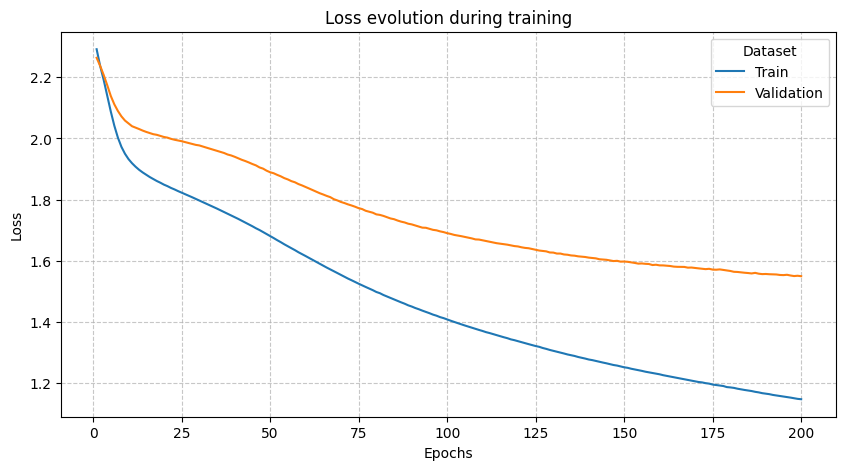

In [20]:
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.models import Sequential

def multiclass_neural_network(learning_rate):
    # Create and compile the model
    
    # Your code here
    
    model = Sequential()
    model.add(Input(shape=(13,)))
    model.add(Dense(128, activation="relu"))
    model.add(Dense(64, activation="relu"))
    model.add(Dense(10, activation="softmax", name="output"))
    optim = Adam(learning_rate = learning_rate)
    
    f1 = F1Score(average="macro")
    model.compile(loss= "categorical_crossentropy", # Complete
                  optimizer=optim, 
                  metrics=[f1])
    
    return model

# Create the network from scratch
model_mtc = multiclass_neural_network(learning_rate = 0.001)
history = model_mtc.fit(Xtr_s, ytr, validation_split = 0.2, batch_size = 64, epochs = 200, verbose = 2)


# Visualize training
# Your code here
plot_loss_history(history)

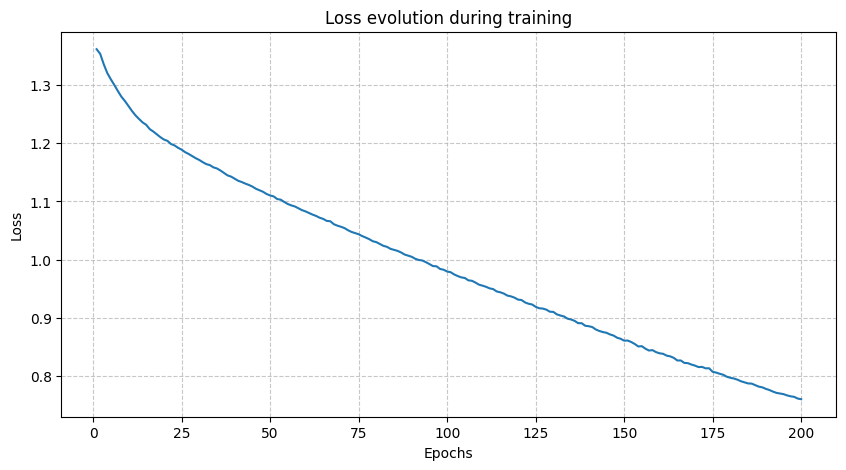

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Results for NNET:
 Métrica     TEST
Accuracy 0.604348
      F1 0.594816



In [21]:
# Train the final model (without validation)
# Your code here
history = model_mtc.fit(Xtr_s, ytr, batch_size= 16, epochs=200, verbose=0)
plot_loss_history(history)
# Evaluate on test
preds_test = (model_mtc.predict(Xte_s))
evaluate_model(np.argmax(yte, axis=1), np.argmax(preds_test, axis=1), "NNET", average="macro")

<hr>

## **4. Multilabel Problems**

The last type of problem we need to address is **multilabel classification**, that is, a problem where each example can belong to **one or more classes**.

<div class="alert alert-block alert-success">
    <b>Develop a model that, given the type of tire and the speed in the first sector (<code>"Compound" and "SpeedI1"</code>), can predict the <i>driver(s)</i> (<code>"Driver"</code>) who have used that combination.</b>
</div>
  
As always, the first step is to create the dataset needed to train and evaluate the different models.

### **4.1. Data Preprocessing**

We create the <code>data_drivers</code> variable with the necessary rows and columns to train our models.

In [22]:
from sklearn.preprocessing import MultiLabelBinarizer

data_drivers = data.groupby(['Compound', 'SpeedI1'])['Driver'].apply(lambda x: x.unique()).reset_index()
# Drivers are encoded as multi-hot
mlb = MultiLabelBinarizer()
driver_dummies = pd.DataFrame(mlb.fit_transform(data_drivers['Driver']), columns = map(lambda x: 'Driver_'+str(x), mlb.classes_))
# Add the new columns encoded as numbers
data_drivers = data_drivers = pd.concat([data_drivers.drop(columns = ['Driver']), driver_dummies], axis = 1)

In [23]:
print(len(data_drivers.columns))

22


<div class="alert alert-block alert-info">
    <b>Exercise:</b> Separate the X and Y from the <code>data_drivers</code> dataframe, split into training and test (80/20) setting the seed, and finally <b>normalize</b> the X using the <code>MinMaxScaler()</code> class.
    <hr style="margin-bottom:5px">
    You may need to encode some of the columns.
</div>

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
data_drivers = pd.get_dummies(data_drivers, dtype=int)
X_cols = ["SpeedI1", "Compound_HARD", "Compound_INTERMEDIATE", "Compound_MEDIUM", "Compound_SOFT", "Compound_WET"]
y_cols = ['Driver_ALB', 'Driver_ALO', 'Driver_BOT',
       'Driver_DEV', 'Driver_GAS', 'Driver_HAM', 'Driver_HUL', 'Driver_LEC',
       'Driver_MAG', 'Driver_NOR', 'Driver_OCO', 'Driver_PER', 'Driver_PIA',
       'Driver_RUS', 'Driver_SAI', 'Driver_SAR', 'Driver_STR', 'Driver_TSU',
       'Driver_VER', 'Driver_ZHO']

X = data_drivers[X_cols]
y = data_drivers[y_cols]

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed)
sc = MinMaxScaler()
Xtr_s = sc.fit_transform(Xtr)
Xte_s = sc.transform(Xte)

### **4.2. Machine Learning**

With the data ready, we will train and evaluate the already known machine learning models to compare them with our new system.

<div class="alert alert-block alert-warning">
    <strong>Note:</strong> Remember that the <code>f1_score</code> can be obtained in different ways in problems with multiple classes. In this case, <code>samples</code> seems to be the best option.
</div>

In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

# Baseline Random
baseline_random = DummyClassifier(strategy = 'uniform')
baseline_random.fit(Xtr_s, ytr)
preds_test = baseline_random.predict(Xte_s)
evaluate_model(yte, preds_test, 'Baseline Random', average = 'samples')

# Baseline Zero-R
baseline_zero = DummyClassifier(strategy = 'most_frequent')
baseline_zero.fit(Xtr_s, ytr)
preds_test = baseline_zero.predict(Xte_s)
evaluate_model(yte, preds_test, 'Baseline Zero-R', average = 'samples')

# KNN
model_knn = KNeighborsClassifier()
model_knn.fit(Xtr_s, ytr)
preds_test = model_knn.predict(Xte_s)
evaluate_model(yte, preds_test, 'KNN', average = 'samples')

# Decision Trees
model_tree = DecisionTreeClassifier()
model_tree.fit(Xtr_s, ytr)
preds_test = model_tree.predict(Xte_s)
evaluate_model(yte, preds_test, 'Tree', average = 'samples')

Results for Baseline Random:
 Métrica     TEST
Accuracy 0.000000
      F1 0.246266

Results for Baseline Zero-R:
 Métrica  TEST
Accuracy   0.0
      F1   0.0

Results for KNN:
 Métrica     TEST
Accuracy 0.142857
      F1 0.451829

Results for Tree:
 Métrica     TEST
Accuracy 0.190476
      F1 0.487381



The results should look something like this:

<center>

| Model               | Accuracy (test) | F1 samples (test) |
|---------------------|-----------------|-------------------|
| Baseline Random     | 0.000           | 0.206             | 
| Baseline Zero-R     | 0.000           | 0.000             |
| KNN                 | 0.143           | 0.452             |
| Decision Trees      | 0.190           | 0.487             |

</center>

### **4.3. Deep Learning**

As always, once we have several machine learning models trained to solve our problem, we will try to create a *neural network* to improve the results.

As you remember, in multiclass problems we had multiple outputs (as many as classes) and each example could only belong to one class. In **multilabel classification** problems like this one, we also have as many outputs as classes, but now <u>an example can belong to one or more classes</u>.

For our neural network, this means we can have several ones as output, so we can use a `sigmoid`.

<div class="alert alert-block alert-warning">
    <strong>Note:</strong> Multilabel classification problems can be seen as <i>multiple binary classification problems in parallel</i>.
</div>

Thus, we will use the same loss and activation function in the final layer as in binary classification. Updating our table of *changes* in neural networks based on the problem, we get the following:

<center>

| Type of problem            | Activation function in the final layer      | Loss function               | In *keras*                                    |
|----------------------------|---------------------------------------------|-----------------------------|-----------------------------------------------|
| *Regression*               | None or *ReLU* (if values are positive)    | *MAE* or *MSE*              | `mean_average_error` or `mean_squared_error`   |
| *Binary Classification*    | *Sigmoid*                                  | *Binary Crossentropy*       | `binary_crossentropy`                         |
| *Multiclass Classification*| *Softmax*                                  | *Categorical Crossentropy*  | `categorical_crossentropy`                    |
| *Multilabel Classification*| *Sigmoid*                                  | *Binary Crossentropy*       | `binary_crossentropy`                         |

</center>

<div class="alert alert-block alert-info">
    <b>Exercise:</b> Create a non-linear multilabel neural network to try to improve traditional machine learning models in this task. Find the best <code>learning rate</code>, train, and evaluate the final model on the test set. Fill in both tables.
    <hr style="margin-bottom:5px">
    Set the validation set to 20%, epochs to 200, and batch size to 64. Remember that for training the final model, the validation set is not necessary.
</div>

<center>

| Model                      | Accuracy (train)  | F1 (train) | Accuracy (val)  | F1 (val) |
|----------------------------|-------------------|------------|-----------------|----------|
| *Neural Network (lr=0.001)* |                   |            |                 |          |
| *Neural Network (lr=0.005)* |                   |            |                 |          |
| *Neural Network (lr=0.01)*  |                   |            |                 |          |

</center>
<br>
<center>

| Model               | Accuracy (test) | F1 samples (test) |
|---------------------|-----------------|-------------------|
| Baseline Random     | 0.000           | 0.206             |
| Baseline Zero-R     | 0.000           | 0.000             |
| KNN                 | 0.143           | 0.452             |
| Decision Trees      | 0.190           | 0.487             |
| Neural Network      |                 |                   |

</center>

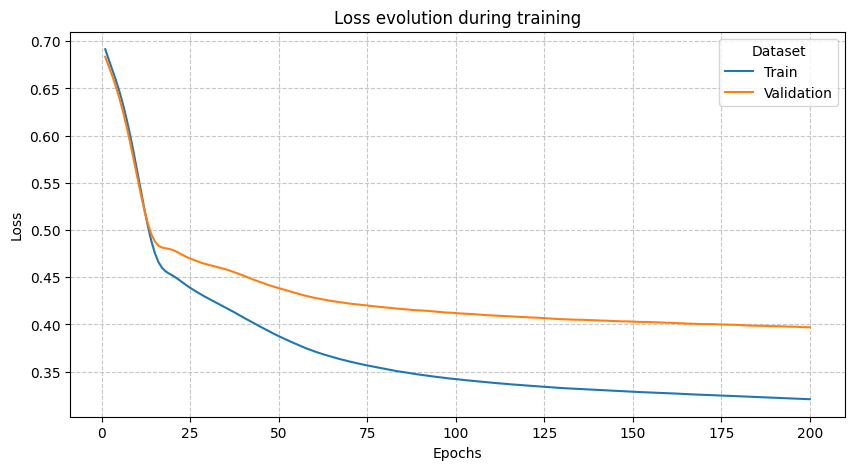

In [26]:
from tensorflow.keras.metrics import F1Score

def neural_network_multilabel(learning_rate):
    # We create and compile the model
    model = Sequential()
    model.add(Input(shape=(6,)))
    model.add(Dense(128, activation="relu"))
    model.add(Dense(64, activation="relu"))
    model.add(Dense(20, activation="sigmoid"))

    optim = Adam(learning_rate=learning_rate)
    
    # Your code here
    f1 = F1Score(average="macro", threshold=0.5)
    
    # Your code here

    model.compile(loss='binary_crossentropy', optimizer=optim, metrics=[f1, "accuracy"])

    return model

# We create the network from scratch
model_mtl = neural_network_multilabel(learning_rate = 0.001)

# We train the model
# Your code here
history = model_mtl.fit(Xtr_s, ytr, validation_split = 0.2, batch_size = 64, epochs = 200, verbose = 0)

# We visualize the training
# Your code here
plot_loss_history(history)

In [27]:
# Train final model (without validation)
# Your code here

# Evaluate on test
preds_test = (model_mtl.predict(Xte_s))
evaluate_model(yte, preds_test>0.5, "NNET", average="samples")

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/stepWARNING:tensorflow:5 out of the last 323 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x12ae91e40> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Results for NNET:
 Métrica     TEST
Accuracy 0.142857
      F1 0.360284



<hr>

## **5. Exercises**

<div class="alert alert-block alert-success">
    <b>Create a model that, given the time (in seconds) of the sectors (<code>"Sector1Time", "Sector2Time", and "Sector3Time"</code>) and the speeds (<code>"SpeedI1", "SpeedI2", "SpeedFL", and "SpeedST"</code>), can predict the <i>tyre</i> (<code>"Compound"</code>) used during the lap.</b>
</div>

In [37]:
# Your code here
X_cols = ["Sector1Time", "Sector2Time", "Sector3Time", "SpeedI1", "SpeedI2", "SpeedFL", "SpeedST"]
y_cols = ["Compound_HARD", "Compound_INTERMEDIATE", "Compound_MEDIUM", "Compound_SOFT", "Compound_WET"]

relevant_cols = ["Sector1Time", "Sector2Time", "Sector3Time", "SpeedI1", "SpeedI2", "SpeedFL", "SpeedST", "Compound"]

data_tyre = data[relevant_cols].copy()
data_tyre = data_tyre.dropna().reset_index(drop=True)

data_tyre["Sector1Time"] = data_tyre["Sector1Time"].dt.total_seconds()
data_tyre["Sector2Time"] = data_tyre["Sector2Time"].dt.total_seconds()
data_tyre["Sector3Time"] = data_tyre["Sector3Time"].dt.total_seconds()

In [38]:
data_tyre = pd.get_dummies(data_tyre, dtype=int)
y_cols = ["Compound_HARD", "Compound_INTERMEDIATE", "Compound_MEDIUM", "Compound_SOFT", "Compound_WET"]
X = data_tyre[X_cols]
y = data_tyre[y_cols]

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

sc = MinMaxScaler()
Xtr_s = sc.fit_transform(Xtr)
Xte_s = sc.transform(Xte)

In [40]:
# Baseline Random
baseline_random = DummyClassifier(strategy = 'uniform')
baseline_random.fit(Xtr_s, ytr)
preds_test = baseline_random.predict(Xte_s)
evaluate_model(yte, preds_test, 'Baseline Random', average = 'samples')

# Baseline Zero-R
baseline_zero = DummyClassifier(strategy = 'most_frequent')
baseline_zero.fit(Xtr_s, ytr)
preds_test = baseline_zero.predict(Xte_s)
evaluate_model(yte, preds_test, 'Baseline Zero-R', average = 'samples')

# KNN
model_knn = KNeighborsClassifier()
model_knn.fit(Xtr_s, ytr)
preds_test = model_knn.predict(Xte_s)
evaluate_model(yte, preds_test, 'KNN', average = 'samples')

# Decision Trees
model_tree = DecisionTreeClassifier()
model_tree.fit(Xtr_s, ytr)
preds_test = model_tree.predict(Xte_s)
evaluate_model(yte, preds_test, 'Tree', average = 'samples')

Results for Baseline Random:
 Métrica     TEST
Accuracy 0.021739
      F1 0.272029

Results for Baseline Zero-R:
 Métrica  TEST
Accuracy   0.0
      F1   0.0

Results for KNN:
 Métrica     TEST
Accuracy 0.830435
      F1 0.830435

Results for Tree:
 Métrica    TEST
Accuracy 0.83913
      F1 0.83913



In [31]:
print(len(data_tyre.columns))

12


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,605 (37.52 KB)

 Trainable params: 9,605 (37.52 KB)

 Non-trainable params: 0 (0.00 B)

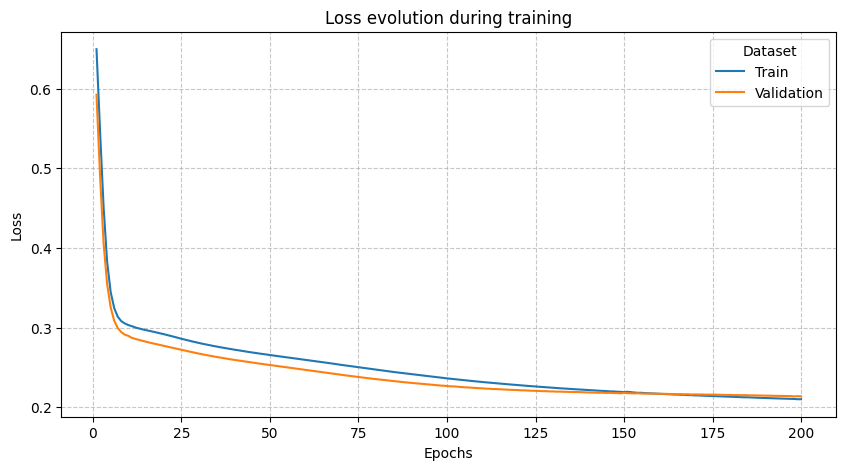

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Results for NNET:
 Métrica     TEST
Accuracy 0.752174
      F1 0.755072



In [41]:
def neural_network_multilabel_2(learning_rate):
    # We create and compile the model
    model = Sequential()
    model.add(Input(shape=(7,)))
    model.add(Dense(128, activation="relu"))
    model.add(Dense(64, activation="relu"))
    model.add(Dense(5, activation="sigmoid"))

    optim = Adam(learning_rate=learning_rate)
    
    # Your code here
    f1 = F1Score(average="macro", threshold=0.5)
    
    # Your code here

    model.compile(loss='binary_crossentropy', optimizer=optim, metrics=[f1, "accuracy"])

    return model

# We create the network from scratch
model_mtl = neural_network_multilabel_2(learning_rate = 0.001)
model_mtl.summary()
# We train the model
# Your code here
history = model_mtl.fit(Xtr_s, ytr, validation_split = 0.2, batch_size = 64, epochs = 200, verbose = 0)

# We visualize the training
# Your code here
plot_loss_history(history)
preds_test = (model_mtl.predict(Xte_s))
evaluate_model(yte, preds_test>0.5, "NNET", average="samples")